## **MINOR PROJECT**
 **Project**:  simpleyard attrition analysis by hr.


# **Importing necessary libs**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as pmat
import seaborn as sea


# **Dataset**

**Dataset link**:https://drive.google.com/file/d/1PoP9AyfgVRlp8gjPgSXpn_DNorQ9-8b2/view?usp=sharing

# **Library configuration**


In [ ]:
import warnings
warnings.filterwarnings('ignore')

# **Importing Dataset**

In [ ]:
dt=pd.read_csv(r'/content/employe.csv')


# **Data Inspection**


In [ ]:
dt.head()

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.37,0.52,2,159,3,0,1,0,sales,low
4,0.41,0.50,2,153,3,0,1,0,sales,low


 **insights**
 * coloumns can be renamed if required.


In [ ]:
#coloumns and their attributes
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfactoryLevel      14999 non-null  float64
 1   lastEvaluation         14999 non-null  float64
 2   numberOfProjects       14999 non-null  int64  
 3   avgMonthlyHours        14999 non-null  int64  
 4   timeSpent.company      14999 non-null  int64  
 5   workAccident           14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotionInLast5years  14999 non-null  int64  
 8   dept                   14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [ ]:
dt.columns

Index(['satisfactoryLevel', 'lastEvaluation', 'numberOfProjects',
       'avgMonthlyHours', 'timeSpent.company', 'workAccident', 'left',
       'promotionInLast5years', 'dept', 'salary'],
      dtype='object')

In [ ]:
#shape of dataset
s=dt.shape
print(f'Rows={s[0]} \nColoumns={s[1]}')

Rows=14999 
Coloumns=10


In [ ]:
#checking for null values in the different columns
dt.isnull().sum()

,0
satisfactoryLevel,0
lastEvaluation,0
numberOfProjects,0
avgMonthlyHours,0
timeSpent.company,0
workAccident,0
left,0
promotionInLast5years,0
dept,0
salary,0


**insights**
* The dataset has **14999** rows and **10** coloumns
* The 10 coloumns are **satisfactoryLevel,lastEvaluation, numberOfProjects, avgMonthlyHours, timeSpent.company, workAccidentleft, promotionInLast5years, dept, salary**
* Coloumns **satisfactoryLevel, lastEvaluation** are of dtype **float64**, **dept, salary** are of **objec**t and the rest are **int64**
* There are **no null values** in any coloumn

# **Data preprocessing**

In [ ]:
dt.isnull().sum()

,0
satisfactoryLevel,0
lastEvaluation,0
numberOfProjects,0
avgMonthlyHours,0
timeSpent.company,0
workAccident,0
left,0
promotionInLast5years,0
dept,0
salary,0


In [ ]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfactoryLevel      14999 non-null  float64
 1   lastEvaluation         14999 non-null  float64
 2   numberOfProjects       14999 non-null  int64  
 3   avgMonthlyHours        14999 non-null  int64  
 4   timeSpent.company      14999 non-null  int64  
 5   workAccident           14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotionInLast5years  14999 non-null  int64  
 8   dept                   14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


**insights**
* since no null values are there in the dataset and the coloumn name seem not to be renamed ,no preprocessing is needed

#**Basic Understanding of Data**

In [ ]:
#no of depatments
x=dt['dept'].nunique()
print(f'departments:{x}')

departments:10


In [ ]:
#types of departments,no of employees left from each department,total resigned and remaining employess,department with highest attrition
x=dt.groupby('dept')['left'].sum()
print(f'departments:{x}')
print(f"\ntotal no of employees left:{dt['left'].sum()}")
print(f"\ntolat no of employees remaining:{dt[dt['left']==0].shape[0]}")
print(f'\nhighest attrition in:{x.idxmax()}:{x.max()}')
print(f'\nlowest attrition in:{x.idxmin()}:{x.min()}')

departments:dept
IT              273
RandD           121
accounting      204
hr              215
management       91
marketing       203
product_mng     198
sales          1014
support         555
technical       697
Name: left, dtype: int64

total no of employees left:3571

tolat no of employees remaining:11428

highest attrition in:sales:1014

lowest attrition in:management:91


In [ ]:
#average no of projects under 1 employee of each department
x=dt.groupby('dept')['numberOfProjects'].mean().round()
print(f'average no of projects under 1 employee of department:{x}')

average no of projects under 1 employee of department:dept
IT             4.0
RandD          4.0
accounting     4.0
hr             4.0
management     4.0
marketing      4.0
product_mng    4.0
sales          4.0
support        4.0
technical      4.0
Name: numberOfProjects, dtype: float64


In [ ]:
#types of salary
print(dt['salary'].unique())

['low' 'medium' 'high']


In [ ]:
#no of low,medium,high employees in each dept
x = dt.groupby(['dept', 'salary']).size().unstack(fill_value=0)
print(x)

salary       high   low  medium
dept                           
IT             83   609     535
RandD          51   364     372
accounting     74   358     335
hr             45   335     359
management    225   180     225
marketing      80   402     376
product_mng    68   451     383
sales         269  2099    1772
support       141  1146     942
technical     201  1372    1147


In [ ]:
#max no of low,meadim and high salary jobs and in which department
x = dt.groupby(['dept', 'salary']).size().unstack(fill_value=0)
print(f"max low sal jobs:{x['low'].idxmax()}\nmax medium sal jobs:{x['medium'].idxmax()}\nmax high sal jobs:{x['high'].idxmax()}")
print(f"\nmin low sal jobs:{x['low'].idxmin()}\nmin medium sal jobs:{x['medium'].idxmin()}\nmin high sal jobs:{x['high'].idxmin()}")



max low sal jobs:sales
max medium sal jobs:sales
max high sal jobs:sales

min low sal jobs:management
min medium sal jobs:management
min high sal jobs:hr


In [ ]:
#no of low,medium,high salary employees left from each department ,total left from each salary catogery and depart with highest
#lowest from each salary catogery
x = dt[dt['left']==1].groupby(['dept', 'salary']).size().unstack(fill_value=0)
print(x)
print(f"\nhighest attrition in high salary:{x['high'].idxmax()},{x['high'].max()}")
print(f"lowest attrition in high salary:{x['high'].idxmin()},{x['high'].min()}")
print(f"\nhighest attrition in medium salary:{x['medium'].idxmax()},{x['medium'].max()}")
print(f"lowest attrition in meadium salary:{x['medium'].idxmin()},{x['medium'].min()}")
print(f"\nhighest attrition in low salary:{x['low'].idxmax()},{x['low'].max()}")
print(f"lowest attrition in low salary:{x['low'].idxmin()},{x['low'].min()}")
print(f"\ntotal attrition in low salary:{x['low'].sum()}")
print(f"total attrition in medium salary:{x['medium'].sum()}")
print(f"total attrition in high salary:{x['high'].sum()}")


salary       high  low  medium
dept                          
IT              4  172      97
RandD           4   55      62
accounting      5   99     100
hr              6   92     117
management      1   59      31
marketing       9  126      68
product_mng     6  105      87
sales          14  697     303
support         8  389     158
technical      25  378     294

highest attrition in high salary:technical,25
lowest attrition in high salary:management,1

highest attrition in medium salary:sales,303
lowest attrition in meadium salary:management,31

highest attrition in low salary:sales,697
lowest attrition in low salary:RandD,55

total attrition in low salary:2172
total attrition in medium salary:1317
total attrition in high salary:82


In [ ]:
#avg monthly hr of a employee wrt to the department and the highest and lowest
x = dt.groupby(['dept'])['avgMonthlyHours'].mean().round(0)
print(x)
print(f'\nhighest avg hr in:{x.idxmax()},{x.max()}')
print(f'\nlowest avg hr in:{x.idxmin()},{x.min()}')

dept
IT             202.0
RandD          201.0
accounting     201.0
hr             199.0
management     201.0
marketing      199.0
product_mng    200.0
sales          201.0
support        201.0
technical      202.0
Name: avgMonthlyHours, dtype: float64

highest avg hr in:IT,202.0

lowest avg hr in:hr,199.0


In [ ]:
#avg time spent by an employee who has left the company in the company from each department, department with highest and lowest
x = dt[dt['left']==1].groupby(['dept'])['timeSpent.company'].mean().round(1)
print(x)
print(f"\ndepartment with highest:{x.idxmax()},{x.max()}")
print(f'\ndepartment with lowest:{x.idxmin()},{x.min()}')

dept
IT             3.9
RandD          4.0
accounting     3.8
hr             3.8
management     3.8
marketing      3.9
product_mng    4.0
sales          3.8
support        3.9
technical      4.0
Name: timeSpent.company, dtype: float64

department with highest:RandD,4.0

department with lowest:accounting,3.8


In [ ]:
#total no of promotions given in the last 5 yrs from each department,department with highest and lowest promo given
x = dt.groupby(['dept'])['promotionInLast5years'].sum().round(2)
print(x)
print(f"\ndepartment with highest promos given:{x.idxmax()},{x.max()}")
print(f'\ndepartment with lowest lowest promos given:{x.idxmin()},{x.min()}')


dept
IT               3
RandD           27
accounting      14
hr              15
management      69
marketing       43
product_mng      0
sales          100
support         20
technical       28
Name: promotionInLast5years, dtype: int64

department with highest promos given:sales,100

department with lowest lowest promos given:product_mng,0


In [ ]:
#  total no of resigned employees  were in a work accident/s,department with highest and lowest
x = dt[dt['left']==1].groupby(['dept'])['workAccident'].sum().round(2)
print(x)
print(f"total no of work accidents:{x.sum()}")
print(f"\ndepartment with highest :{x.idxmax()},{x.max()}")
print(f'\ndepartment with lowest :{x.idxmin()},{x.min()}')

dept
IT              9
RandD          10
accounting      9
hr              7
management      5
marketing      10
product_mng     9
sales          46
support        31
technical      33
Name: workAccident, dtype: int64
total no of work accidents:169

department with highest :sales,46

department with lowest :management,5


In [ ]:
# no of promoted and non promoted employees leaving
promoted = dt[dt['promotionInLast5years'] == 1]
not_promoted = dt[dt['promotionInLast5years'] == 0]

left_promoted = promoted['left'].mean() * 100
left_not_promoted = not_promoted['left'].mean() * 100

print(f"Attrition rate - promoted: {left_promoted:.2f}%")
print(f"Attrition rate - not promoted: {left_not_promoted:.2f}%")

Attrition rate - promoted: 5.96%
Attrition rate - not promoted: 24.20%


**insights**
* There are 10 departments:IT,RandD,accounting,hr,management,marketing,product_mng,sales,support,technical.

* Total no of employees left: 3571,tolat no of employees remaining: 11428,with the attrition rates each department were found with
highest attrition in: sales: 1014, lowest attrition in:management:91.

* Salary is divided into 3 catogories: low,medium and high,with the highest no of low,medium and high salary jobs all in sales while the least no of low in managment,mediumin in managment and high salary jobs in hr.

* (highest attrition in high salary:technical:25,,lowest attrition in high salary:management:1),(highest attrition in medium salary:sales:303
,,lowest attrition in medium salary:management:31),(highest attrition in low salary:sales:697,,lowest attrition in low salary:RandD:55)(total attrition in low salary:2172, in medium salary:1317, in high salary:82).

* The average monthly hrs of an employee wrt to each department were found with highest avg hr in:technical,202.5,lowest avg hr in:hr,198.68.

* The total no of promotions given in the last 5 yrs were found ,with department with highest promos given:sales:100,department with lowest lowest promos given:product_mng:0.

* the time spent (yrs) by employees wrt to each department  who left the company were found, with department with highest:RandD,4.0,department with lowest:accounting,3.8.

* the avg no of projected under an employee in all departments is  around 4.

* the total of workaccident occured to resigned employees occured are 169 and the no of accidents occured wrt to each department were found out,with department with highest :sales:46,department with lowest :management:5

* those who are promoted are more likely to stay than those who arent as attrition in promoted is 5-6% while in not promoted is 24%.

#**Statistical Derivation**

In [ ]:
dt.describe().T

,count,mean,std,min,25%,50%,75%,max
satisfactoryLevel,14999.0,0.612834,0.248631,0.09,0.44,0.64,0.82,1.0
lastEvaluation,14999.0,0.716102,0.171169,0.36,0.56,0.72,0.87,1.0
numberOfProjects,14999.0,3.803054,1.232592,2.00,3.00,4.00,5.00,7.0
avgMonthlyHours,14999.0,201.050337,49.943099,96.00,156.00,200.00,245.00,310.0
timeSpent.company,14999.0,3.498233,1.460136,2.00,3.00,3.00,4.00,10.0
workAccident,14999.0,0.144610,0.351719,0.00,0.00,0.00,0.00,1.0
left,14999.0,0.238083,0.425924,0.00,0.00,0.00,0.00,1.0
promotionInLast5years,14999.0,0.021268,0.144281,0.00,0.00,0.00,0.00,1.0


**insights**
* the data derived also has the data of resigned employees and isn't filtered.

* the average satisfaction is 61%,with some employess having as low as 9%,but 50% of employees have a 64% satisfaction level.

* the average score on the last evaluation is 71.61%,lowest being 9%,highest being  perfect 100%,around 50% of employees have a score of 72%.

* any employee on average has 4 projects under him/her,some having low as 2 while some having as high as 7,50% of employees have 3 projects under them.

* an enployee's average monthly work hours is aroun 201.5 hrs,lowest being 96 hrs,higest being 310 hrs,50% of employees have 200 hrs.

* around 14.46% of employees have met with an work accident.

* nearly 24% of employees have resigned,a considerable chuck of the company.

* only a little over 2.12% of employees were given a promotion in the last 5 yrs.


In [ ]:
dt.describe(include='O').T

,count,unique,top,freq
dept,14999,10,sales,4140
salary,14999,3,low,7316


**insights**
* most employees are under the sales department ,with the no of jobs being 4140.

* most jobs are of low salary, the count being 7316 jobs.

# **Graphs and Analysis**

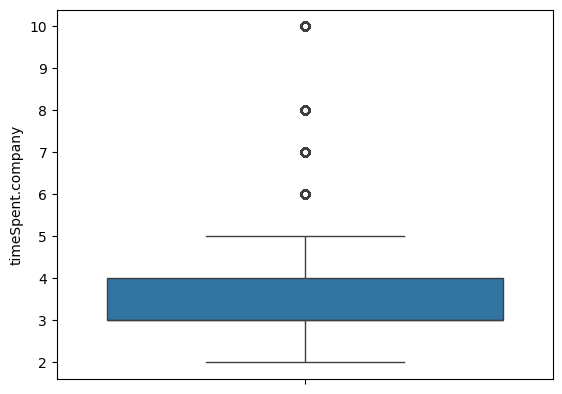

In [ ]:
sea.boxplot(data=dt,y='timeSpent.company')
pmat.show()

**The above data of time spent in company has outliers so do all the  other columns have outliers too so the data must be processed and the outliers from the coloumns must be removed.**

**But the values in some columns must not be processed and their outliers to be removed like to preserve accuracy of data like 'timespent.company',as long tenures are valid and short tenures are common and these outliers may show patterns of why do they resign.An another coloumn is 'left', as it has on 0 or 1 as values, outlier removal isnt possible**

**Therefore,column 'avgMonthlyHours' only needs its outliers removed,**

In [ ]:
#function to find the lower and upper fence of the data series
u,l,x,y=0,0,0,0
def rev_out(dc):
  q1=np.percentile(dc,25)
  q3=np.percentile(dc,75)
  i=q3-q1
  u=q3+(1.5*i)#upper limit
  l=q1-(1.5*i)#lower limit
  return u,l
dt2=dt
x,y=rev_out(dt['avgMonthlyHours'])#x=u,y=l
dt2=dt[(dt['avgMonthlyHours']>=y) & (dt['avgMonthlyHours']<=x)]
dt2.head()


,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.37,0.52,2,159,3,0,1,0,sales,low
4,0.41,0.50,2,153,3,0,1,0,sales,low


**Now the data has been removed of outliers,plotting a heatmap is an easy way to find relationships btw the different varaibles(coloumns)**

**To add catgorical coloumns salary,dept,hot encoding must be done**

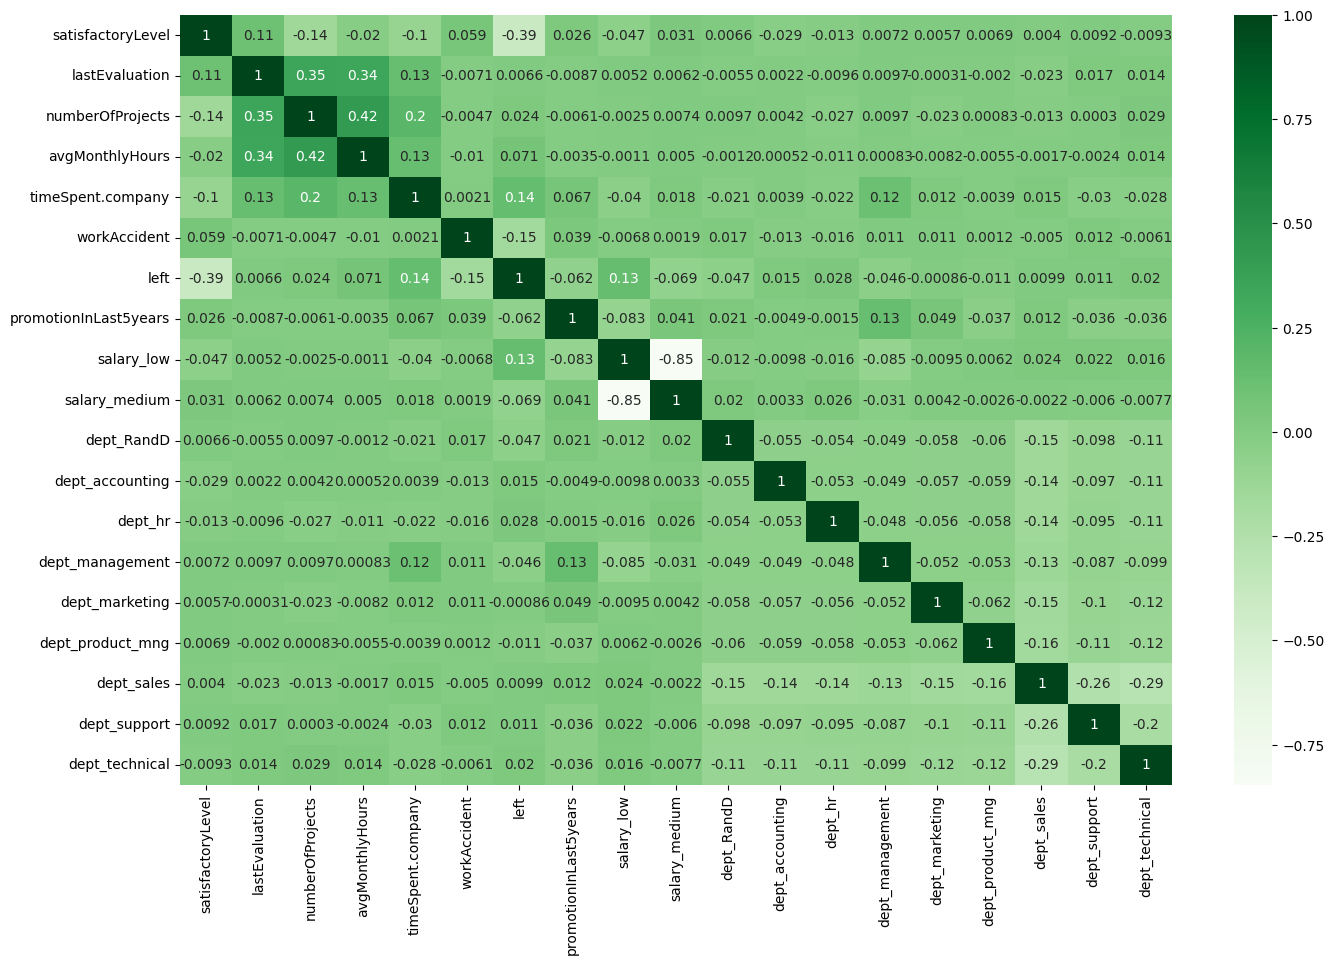

In [ ]:
dt3=pd.get_dummies(dt2,columns=['salary','dept'],drop_first=True)
cm=dt3.corr()
pmat.figure(figsize=(16, 10))
sea.heatmap(cm,annot=True,cmap='Greens')
pmat.show()


**insights**
* no of projects under an employee vs time spent in company have a strong positive correlation(+0.2),meaning having more projects increases the time of employee spending in company.

* avgmonthyhrs vs left have a slight positive correlation(+0.071),meaning increase in work hrs can slightly increase the chance of an employee leaving.

* no of projects vs left have a slight positive correlation(+0.024),meaning overloading the no of projects under an employee increases the chance of leaving slighly.

* salary_low vs left have a weak positive correlation(+0.16) and salary_medium vsleft have a very weak negetive correlation(-0.069),meaning low salary employees are more likely to leave than medium salary ones.

* promotions in last 5 yrs vs left have a weak negetive correlation(-0.062),meaning increasing promotions slightly lowers the risk of attrition of employees.

* time spent in company vs left have a weak positive correlation(0.14),meaning older and more experinced employess are more likely to leave the company.



**To prove the above insights,lets look at sum graphs and charts to prove it and understand the data better**

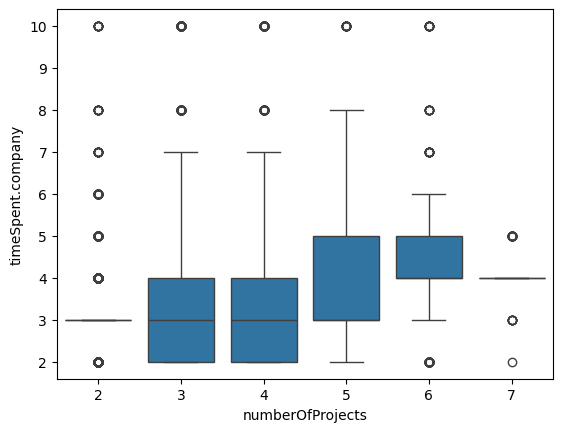

In [ ]:
#no of projects vs time spent in company
sea.boxplot(data=dt2,x='numberOfProjects',y='timeSpent.company')
pmat.show()

**insights**


* Excluding the outliers,  all employess with 2 projects tend to have a tenure of 3 yrs in this company with no median,Q1,Q3 due very little variation in time spent in company among them.

* Excluding the outliers, all employess with 3-4 projects tend to have 2-4 yr tenure in the company with median being 3yrs.

* Excluding the outliers,employess with 5 projects likely have have a 3-5 yr tenure and those with 6 projects tend to have a 4-5 yr tenure.they dont have a median ,which might be due to all employees having identical/same tenure or only a small amout of employess having 5-6 projects under them.

* Excluding the outliers, like employess under 2 projects, almost all those with 7 projects under them only have 4 yr tenure before leaving.

* the outliers show that there are 4 types of extreme employees:new underutilized,new high performing,old underutilized, old high performing.

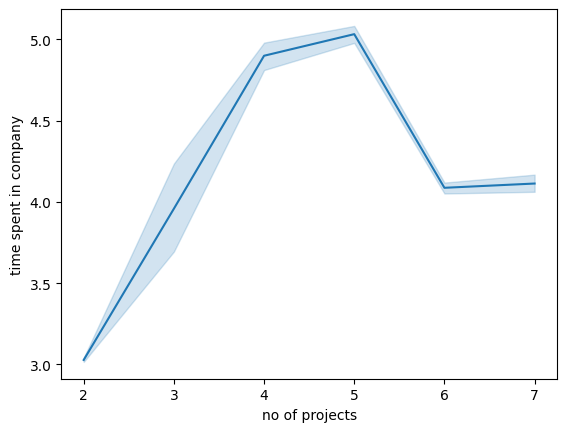

In [ ]:
#time spent in company vs no of project under employees who left
a=dt2[dt2['left']==1]
nj=a['numberOfProjects'].value_counts()
tc=a['timeSpent.company'].value_counts()
sea.lineplot(data=a,x='numberOfProjects',y='timeSpent.company')
pmat.xlabel('no of projects')
pmat.ylabel('time spent in company')

pmat.show()

**insights**
* the time spent by those who left the company increases linearly wih the no of projects from 2 to 4 projects with the yrs increasing from 3 to near 4.8 yrs then increases slightly to 5 yrs as we go from 4 to 5 projects.

* then the time spent drastically decreases as we from 5 to 6 to near 4.1 yrs and this is same for those with 7 projects.



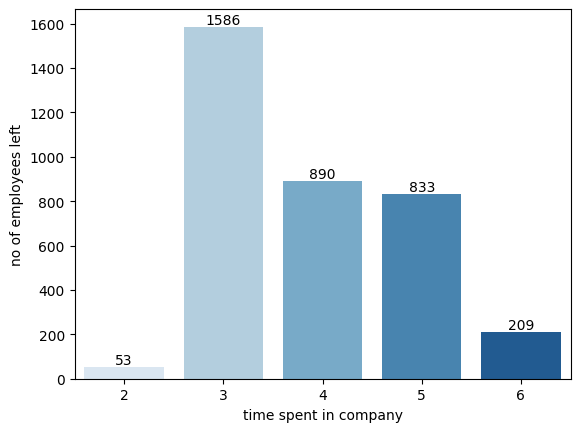

In [ ]:
#time spent in company vs no of employees tha left
a=dt3[dt3['left']==1]
cl=a['timeSpent.company'].value_counts().sort_index()# this is a series
pmat.xlabel('time spent in company')
pmat.ylabel('no of employees left')


ax=sea.barplot(x=cl.index ,y=cl.values,palette='Blues')# cl = series so no nedd to give data=
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # x coordinate (center of bar)
        height,                             # y coordinate (top of bar)
        f'{height:.0f}',                    # label text (rounded integer)
        ha='center',                        # horizontal alignment
        va='bottom'                         # vertical alignment
    )


pmat.show()

**insights**

from the bar chart,the most no of employees who left had a 3 yr tenure while the least were of 2 yrs,meaning employees near or just a little more than 3yr of experience in the company are the  most likely to leave

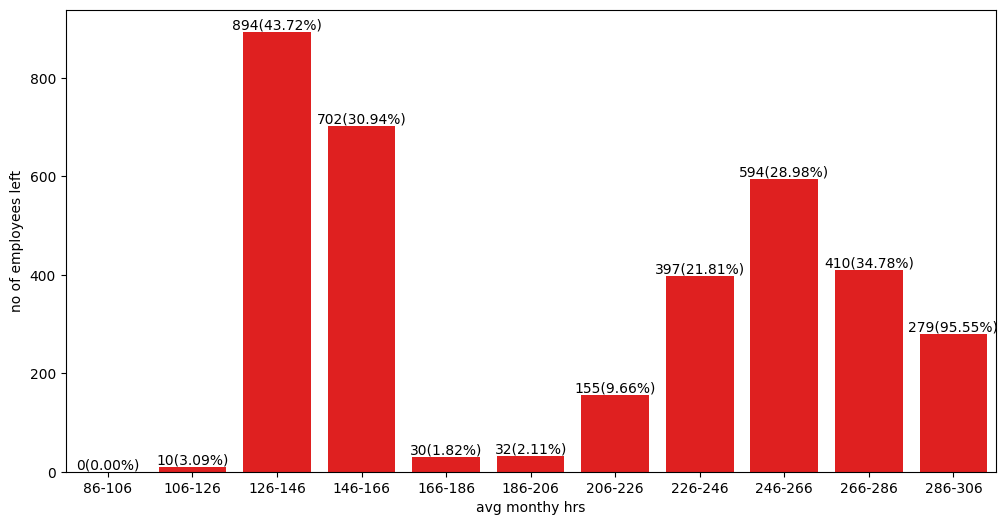

In [ ]:
# avgmonthyhrs in different ranges vs left,with % of leaft employees from each range
a=dt3[dt3['left']==1].copy()
bb=dt3.copy()

b=range(86,310,20) # creating ranges btw 86 -310 hrs
l=[f"{i}-{i+20}"for i in b[:-1]] # creating labels for the ranages

a['hrs_bins']=pd.cut(a['avgMonthlyHours'],bins=b,labels=l,include_lowest=True) #adding extra column for the ranges
bb['hrs_bins_']=pd.cut(bb['avgMonthlyHours'],bins=b,labels=l,include_lowest=True) #adding extra column for the ranges


ck=a['hrs_bins'].value_counts().sort_index()
co=bb['hrs_bins_'].value_counts().sort_index()


pmat.figure(figsize=(12,6))

al=sea.barplot(x=ck.index,y=ck.values,color='red')
dt4=pd.DataFrame({
    'nleft':ck,
    'ntot':co

    })
dt4['l%']=((dt4['nleft']/dt4['ntot'])*100)
dt4=dt4.reset_index()

for i,bar in enumerate(al.patches):
    height = bar.get_height()

    lt=int(dt4.loc[i,'nleft'])
    pt=dt4.loc[i,'l%']

    al.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.0f}({pt:.02f}%)',
        ha='center',
        va='bottom')

pmat.xlabel('avg monthy hrs')
pmat.ylabel('no of employees left')

pmat.show()




**insights**
* most concering are the employees that work 286-306 hrs in a month on avg ,thought no the most amt of employees leaving the company,has this group has its 99.5% of population resigned.

* the highest attrition amt of employeesare those whose avg monthly hrs are 126-146 hrs with 44.72% of these employees of this category have already left the company.

* taking this into consideration:-Low attrition → ~0–10%,Moderate attrition → ~10–30%,High attrition → >30%,the 2nd attrition amt takes place in employees who work 146-166 hrs in a month on avg,with 30.94% of employees leaving.This is important as 146-166 hrs is considered a good avg monthy work hr range.






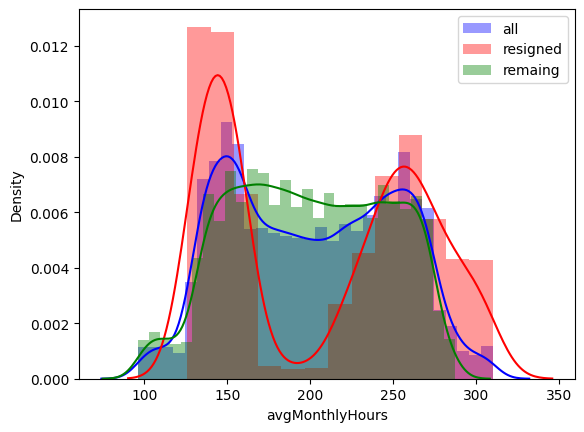

All employees:
  Skewness: 0.052841989416324196
  Kurtosis: -1.1349815681924558

Resigned employees:
  Skewness: 0.05500900054125181
  Kurtosis: -1.628109459929644

Remaining employees:
  Skewness: -0.05530536630740707
  Kurtosis: -0.9937466678917164


In [ ]:
# distribution of total,resigned and remaining employees wrt to thier monthly avd hrs
ae=dt3['avgMonthlyHours'].dropna()
re=dt3[dt3['left'] == 1]['avgMonthlyHours'].dropna()
se=dt3[dt3['left'] == 0]['avgMonthlyHours'].dropna()

a=sea.distplot(dt3['avgMonthlyHours'],label='all',color='blue')
b=sea.distplot(dt3[dt3['left']==1]['avgMonthlyHours'],label='resigned',color='red')
c=sea.distplot(dt3[dt3['left']==0]['avgMonthlyHours'],label='remaing',color='green')


pmat.legend()
pmat.show()

print("All employees:")
print("  Skewness:",ae.skew())
print("  Kurtosis:", ae.kurt())

print("\nResigned employees:")
print("  Skewness:", re.skew())
print("  Kurtosis:", re.kurt())

print("\nRemaining employees:")
print("  Skewness:", se.skew())
print("  Kurtosis:", se.kurt())

**insights**
* all the type of employees have the exactly 2 peaks ,all of them almost fall near 150 and 250 hr mark.

* employees whose avg monthly work hrs near there peaks are the most likely to leave the company and most employees are very near these peaks.

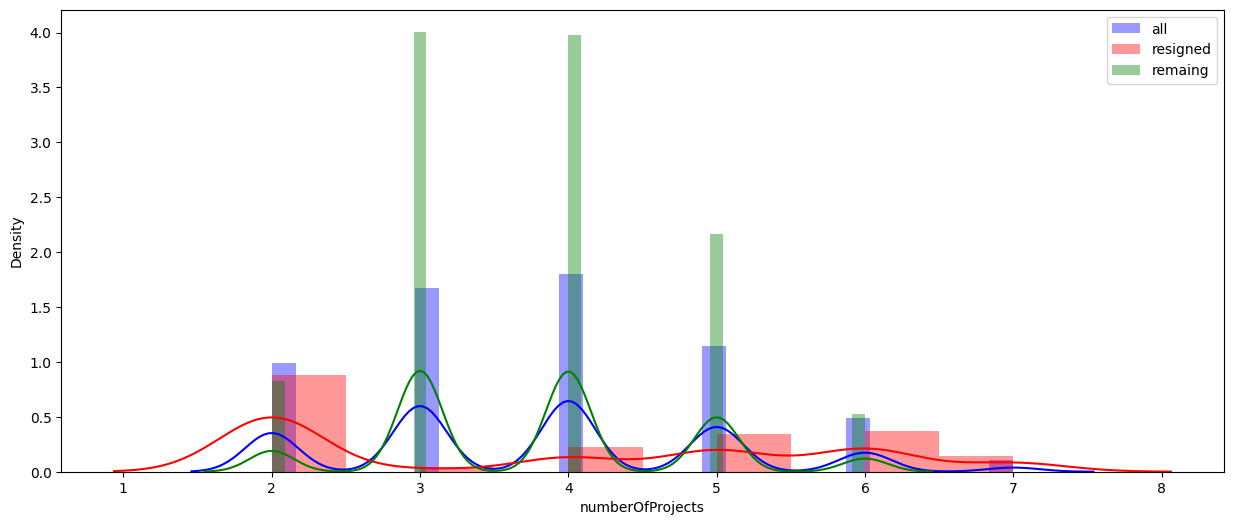

All employees:
  Skewness: 0.3377056123598222
  Kurtosis: -0.4954779519008947

Resigned employees:
  Skewness: 0.24633320833634695
  Kurtosis: -1.4993111805493198

Remaining employees:
  Skewness: 0.26820772394985626
  Kurtosis: -0.43535157250420475


In [ ]:
#distribution of resigned,remaining and all employees wrt to no of projects under them

pmat.figure(figsize=(15,6))

ae=dt3['numberOfProjects'].dropna()
re=dt3[dt3['left'] == 1]['numberOfProjects'].dropna()
se=dt3[dt3['left'] == 0]['numberOfProjects'].dropna()

a=sea.distplot(dt3['numberOfProjects'],label='all',color='blue')
b=sea.distplot(dt3[dt3['left']==1]['numberOfProjects'],label='resigned',color='red')
c=sea.distplot(dt3[dt3['left']==0]['numberOfProjects'],label='remaing',color='green')


pmat.legend()
pmat.show()

print("All employees:")
print("  Skewness:",ae.skew())
print("  Kurtosis:", ae.kurt())

print("\nResigned employees:")
print("  Skewness:", re.skew())
print("  Kurtosis:", re.kurt())

print("\nRemaining employees:")
print("  Skewness:", se.skew())
print("  Kurtosis:", se.kurt())


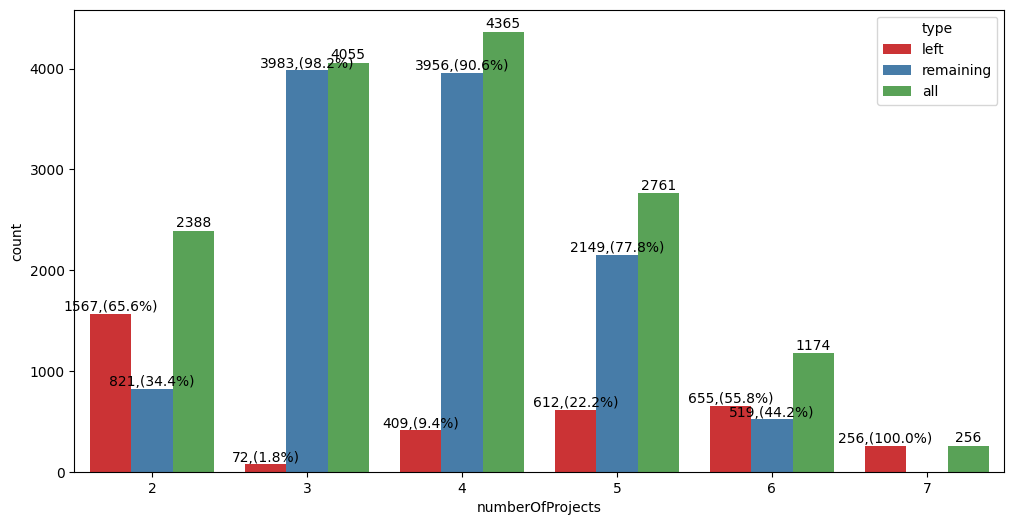

In [ ]:
#distribution of resigned,remaining and all employees from each department
pmat.figure(figsize=(12,6))

dl=dt2[dt2['left']==1].copy()
l=dl['numberOfProjects'].value_counts().sort_index().reset_index(name='count')
l['type']='left'

dr=dt2[dt2['left']==0].copy()
r=dr['numberOfProjects'].value_counts().sort_index().reset_index(name='count')
r['type']='remaining'

da=dt2.copy()
a=da['numberOfProjects'].value_counts().sort_index().reset_index(name='count')
a['type']='all'

xi=pd.concat([l,r,a],ignore_index=True)
tt=xi[xi['type']=='all'][['numberOfProjects','count']].rename(columns={'count':'total'})

xi2=pd.merge(xi,tt,on='numberOfProjects')
xi2['percent']=(xi2['count']/xi2['total'])*100

h=sea.barplot(data=xi2,x='numberOfProjects',y='count',hue='type',palette='Set1')

for bar,(_,row) in zip(h.patches,xi2.iterrows()):
    he = bar.get_height()
    if row['type']=='all':
      label=f"{he:.0f}"
      he+=10
    else:
      label=f"{he:.0f},({row['percent']:.1f}%)"
    h.text(
        bar.get_x() + bar.get_width() / 2,  # x coordinate (center of bar)
        he,                             # y coordinate (top of bar)
        label,                    # label text (rounded integer)
        ha='center',                        # horizontal alignment
        va='bottom'                         # vertical alignment
    )

pmat.show()

**insights**
* all,remaing employees have their peaks and drops almost at the
2,3,4,5,6,7 no of projects mark with the highest being a 3 rd and 4 th in both.this can be considered as a sweet spot for workload limit.

* resigned employees have a very different graph compared to the two other,with the highest peak being a 2 no of projects and 5 and 6 being in 2nd with almost the same peaks.

* almost all employees having 3 no of projects under them are the least likely to resign.


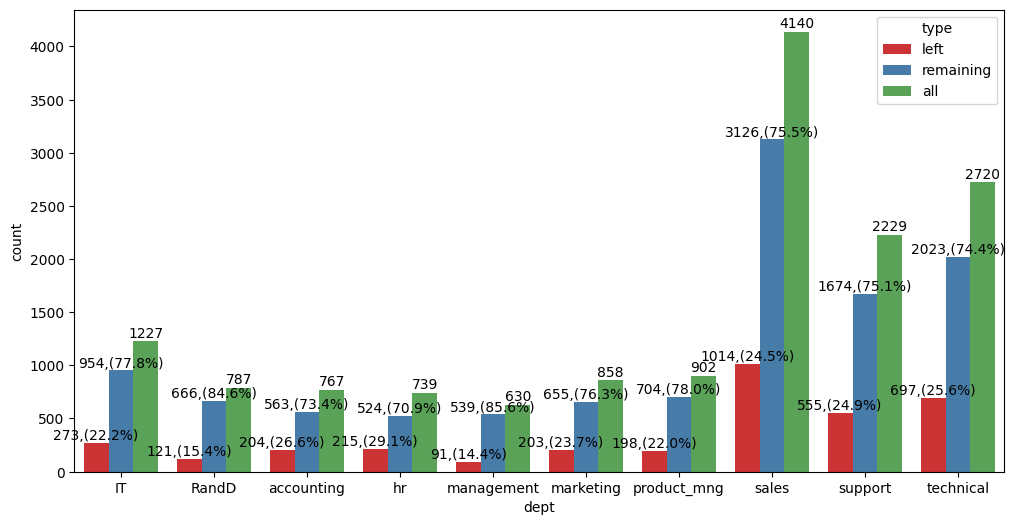

In [ ]:
#distribution of resigned,remaining and all employees from each department
pmat.figure(figsize=(12,6))

dl=dt2[dt2['left']==1].copy()
l=dl['dept'].value_counts().sort_index().reset_index(name='count')
l['type']='left'

dr=dt2[dt2['left']==0].copy()
r=dr['dept'].value_counts().sort_index().reset_index(name='count')
r['type']='remaining'

da=dt2.copy()
a=da['dept'].value_counts().sort_index().reset_index(name='count')
a['type']='all'

xi=pd.concat([l,r,a],ignore_index=True)
tt=xi[xi['type']=='all'][['dept','count']].rename(columns={'count':'total'})

xi2=pd.merge(xi,tt,on='dept')
xi2['percent']=(xi2['count']/xi2['total'])*100

h=sea.barplot(data=xi2,x='dept',y='count',hue='type',palette='Set1')

for bar,(_,row) in zip(h.patches,xi2.iterrows()):
    he = bar.get_height()
    if row['type']=='all':
      label=f"{he:.0f}"
      he+=10
    else:
      label=f"{he:.0f},({row['percent']:.1f}%)"
    h.text(
        bar.get_x() + bar.get_width() / 2,  # x coordinate (center of bar)
        he,                             # y coordinate (top of bar)
        label,                    # label text (rounded integer)
        ha='center',                        # horizontal alignment
        va='bottom'                         # vertical alignment
    )

pmat.show()

**insights**
* highest no of resignations are from the sales department,with a high attrition rate of 24.5%(1040).

* 2nd highest no of resignations are from the support department,with a  slightly higher attrition rate of 24.9%(555)

* the hr department,which doesnt have the highest no of attrition ,with 215 employees leaving,has the highest attrition rate of 29.1%.

* while it,product mnd,marketing also dont have high no of attritions ,their attrition rates are in btw 22-26%.

* most stable/employee retaining departments are r&d and management with 15.4% and 14.4% attrition rates repectively.



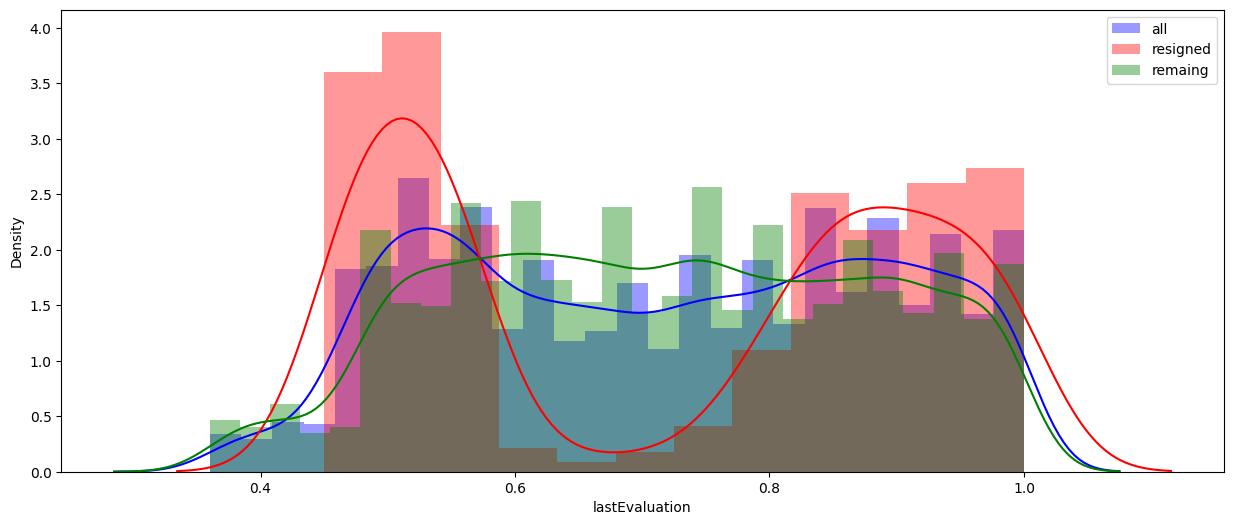

All employees:
  Skewness: -0.026621749863758908
  Kurtosis: -1.2390402819304127

Resigned employees:
  Skewness: -0.013858939499846113
  Kurtosis: -1.7095501775882234

Remaining employees:
  Skewness: -0.03903757595977895
  Kurtosis: -1.0142139960069907


In [ ]:
#distribution of resigned,remaining and all employees wrt to evaluation
pmat.figure(figsize=(15,6))

ae=dt3['lastEvaluation'].dropna()
re=dt3[dt3['left'] == 1]['lastEvaluation'].dropna()
se=dt3[dt3['left'] == 0]['lastEvaluation'].dropna()

a=sea.distplot(dt3['lastEvaluation'],label='all',color='blue')
b=sea.distplot(dt3[dt3['left']==1]['lastEvaluation'],label='resigned',color='red')
c=sea.distplot(dt3[dt3['left']==0]['lastEvaluation'],label='remaing',color='green')

pmat.legend()
pmat.show()

print("All employees:")
print("  Skewness:",ae.skew())
print("  Kurtosis:", ae.kurt())

print("\nResigned employees:")
print("  Skewness:", re.skew())
print("  Kurtosis:", re.kurt())

print("\nRemaining employees:")
print("  Skewness:", se.skew())
print("  Kurtosis:", se.kurt())

**insights**
* the resigned and all employees share their peaks and drops al almost the same last evaluation marks(0.5,0.9).this is concering as the remaining employees also share this very slighly.

* this means very low and vey high scorers are most likely to leave with the very low ones more likely than the latter but still no much difference in height of peaks btw them.

* the avg scorere(0.6-0.8) are most unlikely to leave the company.

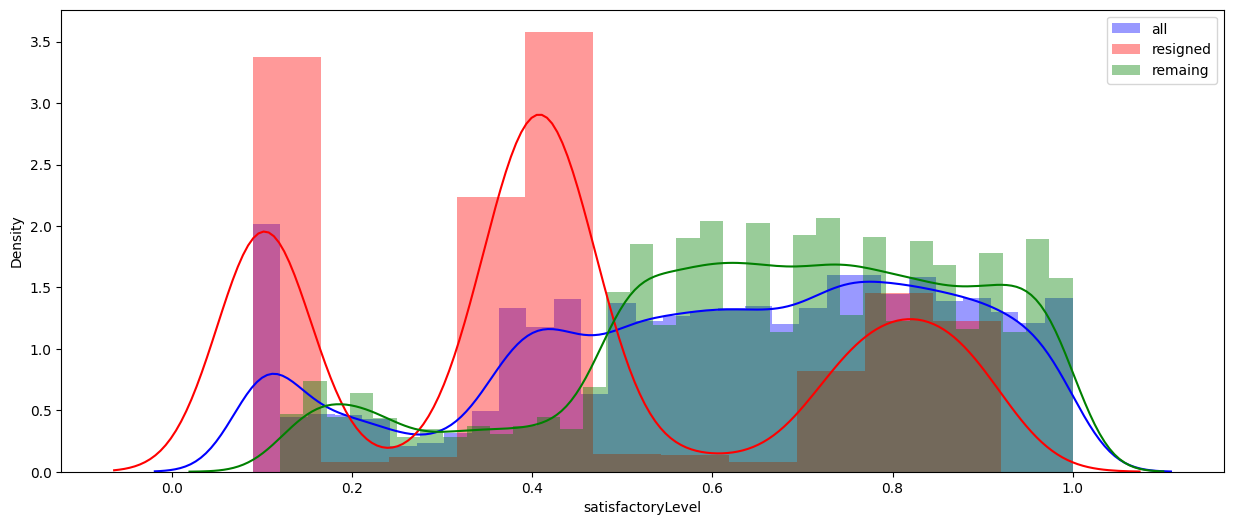

All employees:
  Skewness: -0.47636034128396443
  Kurtosis: -0.6708586220574557

Resigned employees:
  Skewness: 0.2918813344630604
  Kurtosis: -1.0328229301302894

Remaining employees:
  Skewness: -0.604516530965863
  Kurtosis: -0.2151133736599986


In [ ]:
#distribution of resigned,remaining and all employees wrt to satisfactoryLevel
pmat.figure(figsize=(15,6))

ae=dt3['satisfactoryLevel'].dropna()
re=dt3[dt3['left'] == 1]['satisfactoryLevel'].dropna()
se=dt3[dt3['left'] == 0]['satisfactoryLevel'].dropna()

a=sea.distplot(dt3['satisfactoryLevel'],label='all',color='blue')
b=sea.distplot(dt3[dt3['left']==1]['satisfactoryLevel'],label='resigned',color='red')
c=sea.distplot(dt3[dt3['left']==0]['satisfactoryLevel'],label='remaing',color='green')

pmat.legend()
pmat.show()

print("All employees:")
print("  Skewness:",ae.skew())
print("  Kurtosis:", ae.kurt())

print("\nResigned employees:")
print("  Skewness:", re.skew())
print("  Kurtosis:", re.kurt())

print("\nRemaining employees:")
print("  Skewness:", se.skew())
print("  Kurtosis:", se.kurt())

**insights**
* all 3 types of graphs have different peaks and drops with some similarities.

* the resigned employees have 3 peaks,highest being near the 0.4 mark,2nd near 0.1 mark and 3rd near 8.2-8.3 mark.this is concering as remaining employees also have some of heir peaks near these marks.

* almost all employees with satisfaction near 0.2 and 0.6 are the least likely to leave.

# **Conclusion**

After studying and analysising the data thorugh inspection the data head on , drawing drawing strong relationships btw the different variables,we can conclude to the following points:-

* the current workforce is 11428 ,with 3571 employees leaving the company ,that is 31.24% of the company leaving.

* the highest attrition rates are faced by hr(29.1%),accounting(26.6%)technical(25.6%) and sales(24.9%).IT ,product mng and marketing face moderate attrition with rates being in range of 22%-24% while department r&d and managment are the most stable with low rates near 15%.the most no of employees left

* employees with less than 3 project are the more likely to leave but not most likely,as those with 2 projects under them have an attrition rate of 65.5%,its only the 2nd highest attrition and more than those with 5 or 6 under them, the highest is tthose who have 7 projects under them where the attrition rate is 100%.

* the time spent by those who left the company increases linearly wih the no of projects from 2 to 4 projects with the yrs increasing from 3 to near 4.8 yrs then increases slightly to 5 yrs as we go from 4 to 5 projects, then the time spent drastically decreases as we from 5 to 6 to near 4.1 yrs and this is same for those with 7 projects.

* compensation levels are a key factor in an employees decision to leaving as the no of employees left are from the low salary category and no decreases as go to medium and futher in high salary employee resignations.

# **Key Factor for Attrition**

#  **department distribution:**
* in departments with large no of employees like sales,technical and support,their high attritionit might not be due the workload per employee on avg as the workforce in these departmnets are high in nos,it might be due to factors like low salary as sales has the most no of low salary employees and they are the most likely to leave wrt to the salary category.other factor may be long work hrs as technical and support has one of the highest avg monthly hrs.high salary group of technical and sales are somewhat of an exception as,they have the most number of high salary resigned employees,which might indicate a work overload problem within the high salary employees of the departments.

* in departments with low workforce,work overload might be their key reason for high and moderate attrition rates.

# **no of projects:**
* no of projects under an employee is a major factor to predict his/her decision of resigning.as we saw,no of projects not only affects the attrition but also the tenure of the employee.those under 2 projects are the most likely to resign within 3yrs of starting,this might be due to bordem or personel infulmilment in work amt done.

* but increasing the no of projects doesnt increase attrition and decrease tenure upto a certain level,as upto 5 projects the attrion rate is very low and the tenure of the employee increases with each project upto 5 but as we go to 6,the attrition slightly increases and tenure drastically decreases compared to that of someone with 5 projects and 7 projects gurenttes 100% attrition chance of employee

# **avg monthly hrs of an employee:**

* this is an another major factor for attrion rates as increasing it after certain limits increases.as saw,those whose avg monthly hrs are btw 286-306 have a 99.5% chance of leaving.

* but there are somewhat 2 sweet spot with max hr and good chance of not leaving are low which can be seen from the graphs, most of those who didnt leave the company have their avg monthly hrs near 150 and 250 th mark but these marks are also where the no of resigned are at their peak

* those near the 200 th mark,who is a less no of hrs than the 250th,are the last likely to leave the company.

# **salary of an employee**
* salary is a major factor for resignation of many employees as the most attrition is seem in low salary employees as they accont 60% of the resigned workforce,this has lead to a major decrease in personnel in sales as it has the highest no of low salary jobs,this shows the  main reason of resigning of these employees is the low salary

* medium salary resigned employees are about 36% of the left workforce and have the same resons as for those with low salary.

* high salary compared to the two only accounts for 2.3% of the left employees,might be due to work overload,personal unfulfilment in work done or better job offers recieved from other companies.

# **promotions given**

* from the heat map,no of promotions given vs no of employees leaving though have a weak correlation but is also a major factor for attrition.

* the attrition amoung those who are promoted in th company is 5-6% while among those not promoted is 24% a near 4x increase in attrition rate.





# **Measure to reduce attrition**
* **Doing surveys:**
doing survey among departments,employees with extreme work hrs,those with  score btw 0.4-0.6 and 0.8-1.0 in the last evaluation,those with satisfactory level near 1,4,8 and those whose avg monthly hrs are near 150 or 250 hrs.

* **Fixing department workforce and workload:**
increasing workforce in low workforce departments to reduce workload,which can decrease their attrition rates while slightly increasing workloads for those in large workforce.

* **Fixing distribution of no of number of projects:**
give more projcts to those with only 2 projects under them and nearing a 3 yr tenure in the company and those with either of the criteria,the increases no should depend on their skill and performance.reducing the max limit of projects to 5-6 it and immediatly reducing the no of projects under those with 7.

* **Salary hiking:**
salary hiking can reducing attrition ,espacially among the low and medium salary employees,reducing chance of top talent from both category leaving.salaryhiking might also decrease attrition in high salary employees as they are very much needed for optimized functioning of company but must be given wrt to their skill,experience and importance in company.

* **No of promotions increase:**
increasing the no of promotions and giving to top talent and high performance employees can nearly 4x decrease their chances of leaving and also it can aliveate work load among the higher status/top brass of employess to some extent.

* **Reducing min work hours and increasing overtime pay:**
reducing the min work hours wrt to avg workload faced by an employee in each department and increasing overtime pay might attract more employees to work more hrs and reduce the chance of them and thoese with already high hrs under them from leaving.





